In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [2]:
diabetes_dataset = pd.read_csv('D:\Diabeties-prediction\diabetes.csv')
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
diabetes_dataset.shape

(768, 9)

In [4]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [6]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.622000,70.844000,27.170000,117.172000,30.846000,0.429734,31.190000
1,4.865672,142.302239,75.272388,32.671642,187.615672,35.398507,0.550500,37.067164


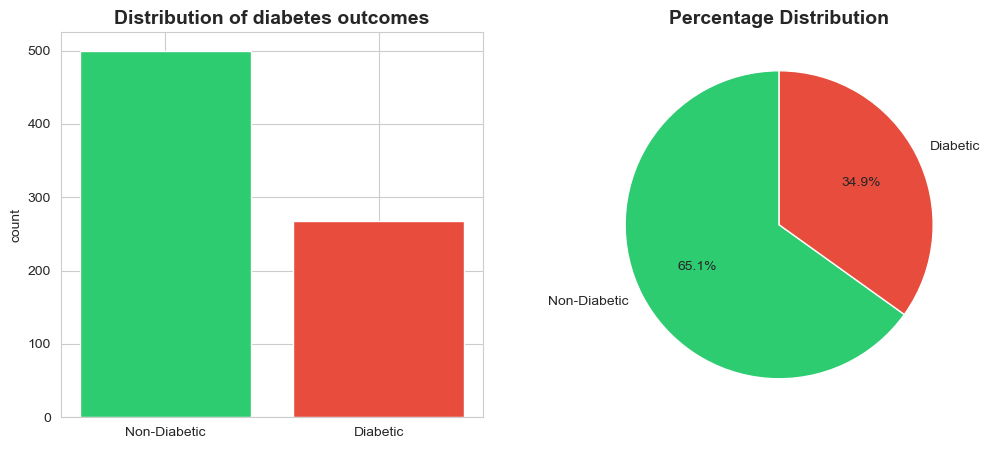

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
outcome_counts = diabetes_dataset['Outcome'].value_counts()

plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['#2ecc71','#e74c3c'])

plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

plt.subplot(1,2,2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)

plt.title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.show()

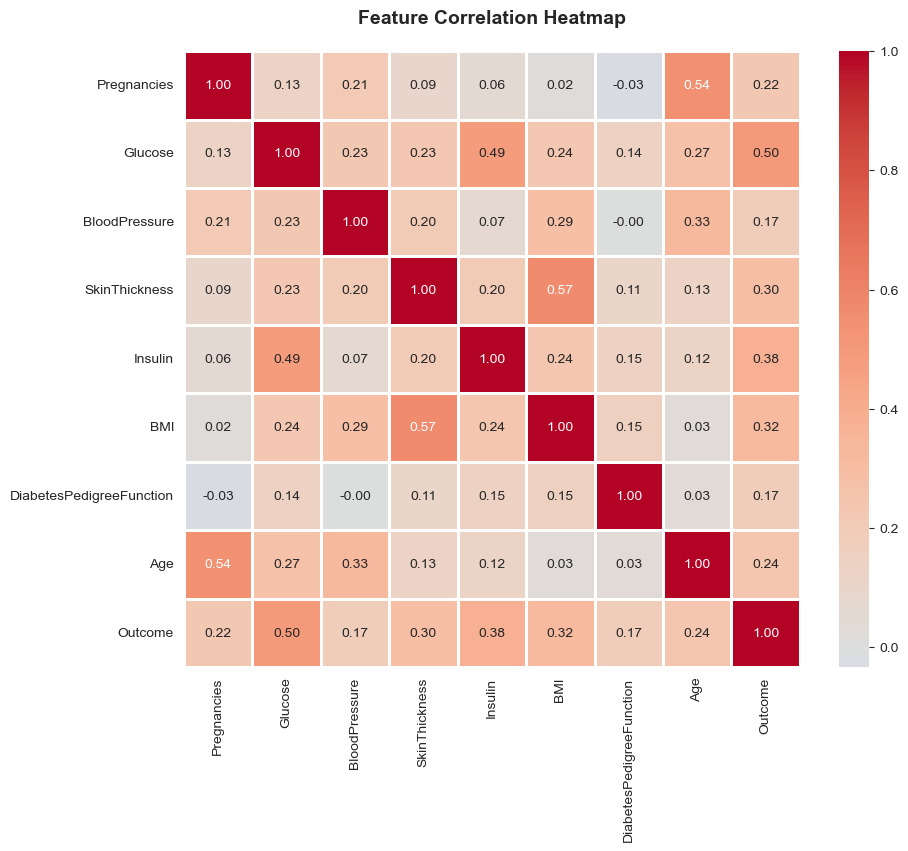

In [8]:
plt.figure(figsize=(10,8))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center = 0, square= True, linewidth=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, pad=20, fontweight='bold')
plt.show()

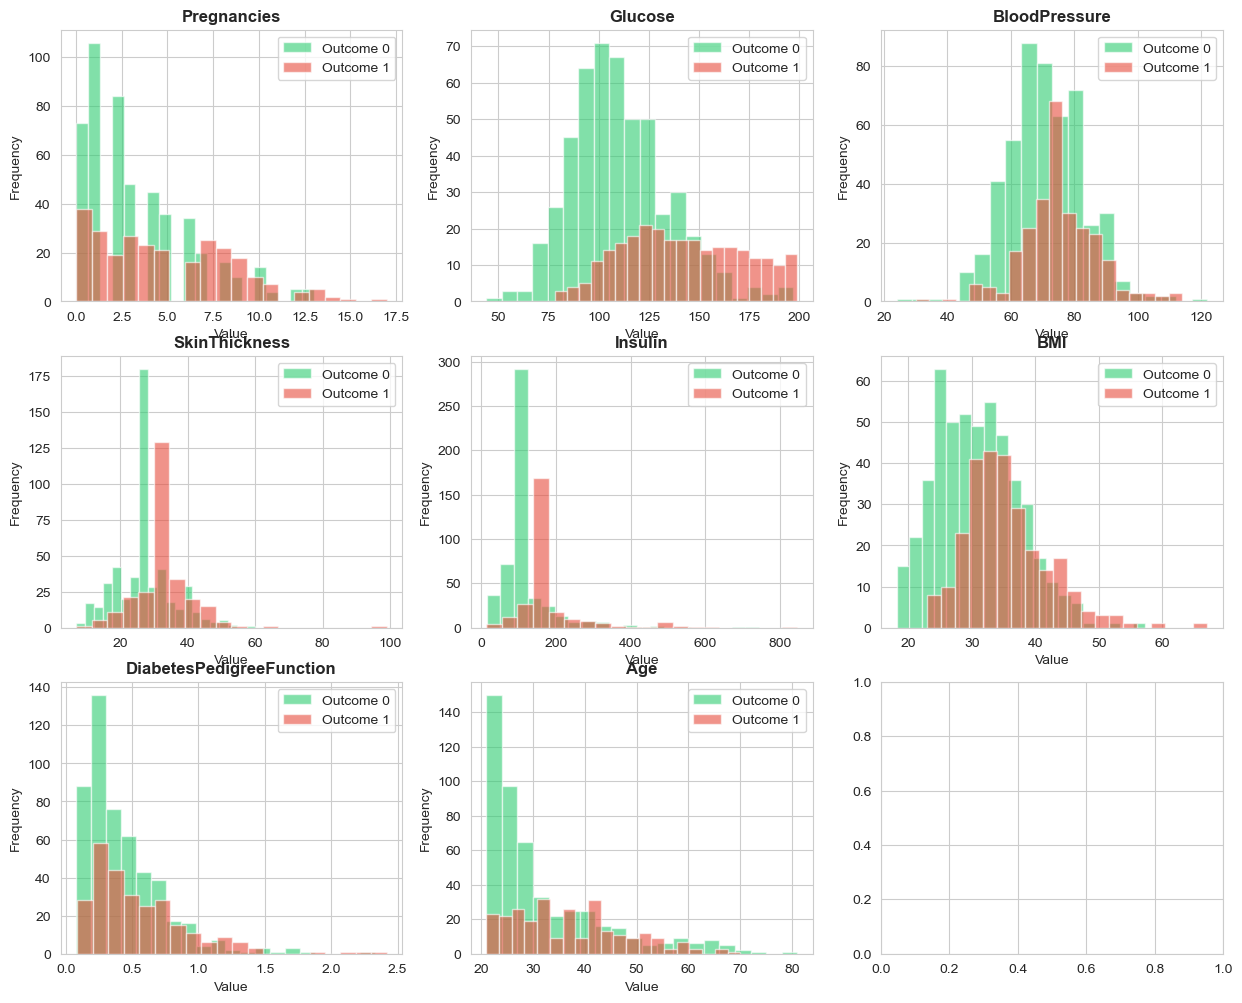

In [9]:
fig, axes = plt.subplots(3,3,figsize=(15,12))
features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx //3, idx % 3
    for outcome in [0,1]:
        data = diabetes_dataset[diabetes_dataset["Outcome"] == outcome][feature]
        axes[row,col].hist(data, alpha=0.6, bins=20, label=f'Outcome {outcome}',
                           color=['#2ecc71', '#e74c3c'][outcome])
        axes[row,col].set_title(feature, fontweight='bold')
        axes[row,col].set_xlabel('Value')
        axes[row,col].set_ylabel('Frequency')
        axes[row,col].legend()
plt.show()

In [10]:
x = diabetes_dataset.drop(columns='Outcome',axis=1)
y = diabetes_dataset['Outcome']

print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148           72.0             35    169.5  33.6   
1              1       85           66.0             29    102.5  26.6   
2              8      183           64.0             32    169.5  23.3   
3              1       89           66.0             23     94.0  28.1   
4              0      137           40.0             35    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101           76.0             48    180.0  32.9   
764            2      122           70.0             27    102.5  36.8   
765            5      121           72.0             23    112.0  26.2   
766            1      126           60.0             32    169.5  30.1   
767            1       93           70.0             31    102.5  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [11]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, stratify=y, random_state=2)

print(x.shape, x_train.shape, x_test.shape)

(768, 8) (614, 8) (154, 8)


In [13]:
classifier = svm.SVC(kernel='linear', probability = True)
classifier.fit(x_train, y_train)

SVC(kernel='linear', probability=True)

In [14]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
training_data_accuracy

0.7850162866449512

In [15]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
test_data_accuracy

0.7532467532467533

In [16]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision, recall, f1)

0.6904761904761905 0.5370370370370371 0.6041666666666666


In [17]:
cm_svm = confusion_matrix(y_test, x_test_prediction)
cm_svm

array([[87, 13],
       [25, 29]], dtype=int64)

<function matplotlib.pyplot.show(close=None, block=None)>

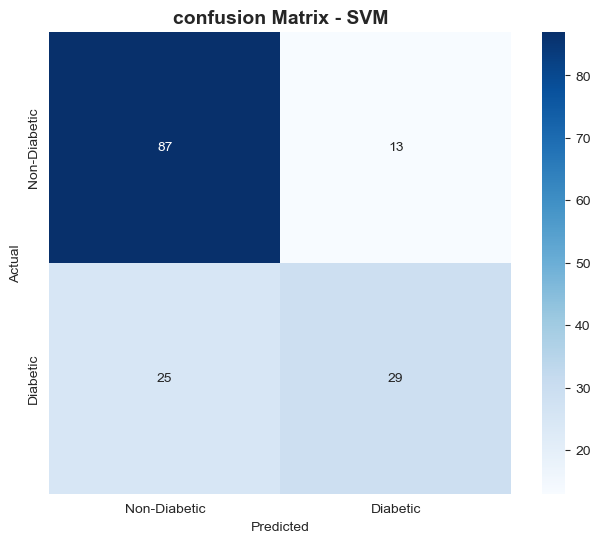

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot= True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show

In [19]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=2)

In [20]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [21]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)
training_data_accuracy_rf

1.0

In [22]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf, y_test)

In [23]:
test_data_accuracy_rf

0.8896103896103896

In [24]:
precision_rf = precision_score(y_test, x_test_prediction_rf)

In [25]:
recall_rf = recall_score(y_test, x_test_prediction_rf)

In [26]:
f1_rf = f1_score(y_test, x_test_prediction_rf)

In [27]:
print(precision_rf,recall_rf,f1_rf)

0.8490566037735849 0.8333333333333334 0.8411214953271028


In [28]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
print(cm_rf)

[[92  8]
 [ 9 45]]


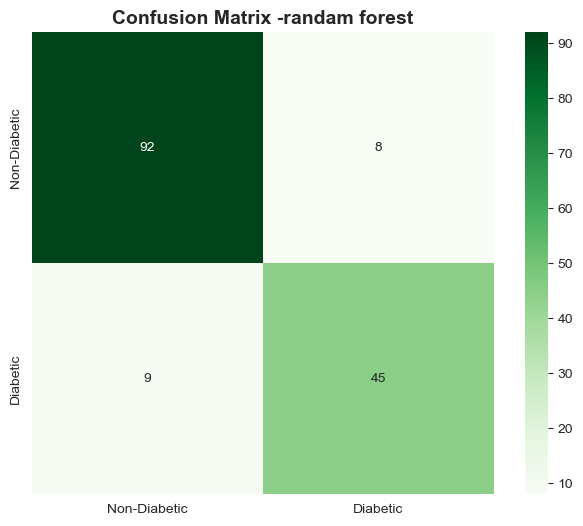

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens",square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('Confusion Matrix -randam forest',fontsize=14, fontweight='bold')
plt.show()

In [30]:
print('SVM',test_data_accuracy)
print('Random forest', test_data_accuracy_rf)

SVM 0.7532467532467533
Random forest 0.8896103896103896


In [31]:
joblib.dump(classifier,'diabetes_model.pkl')

['diabetes_model.pkl']

In [32]:
joblib.dump(scaler, 'scaler_svm.pkl')

['scaler_svm.pkl']

In [33]:
input_data = (95,166,72,19,175,25.8,0.587,51)
input_num_array = np.asarray(input_data)
reshape = input_num_array.reshape(1,-1)

std_data = scaler.transform(reshape)
prediction = classifier.predict(std_data)

In [34]:
prediction

array([1], dtype=int64)